In [1]:
import numpy as np
import astropy.units as u
from astropy.io import fits
import time 
from importlib import reload
import copy
from datetime import datetime
today = int(datetime.today().strftime('%Y%m%d'))
from IPython.display import clear_output

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.patches import Circle, Rectangle

import lina
from lina.math_module import xp, xcipy, ensure_np_array
from lina import dm, utils, shmim_utils, coro_utils, telem

from magpyx.utils import ImageStream
import purepyindi
from purepyindi import INDIClient
import purepyindi2
from purepyindi2 import IndiClient

client0 = INDIClient('localhost', 7624)
client0.start()

client = IndiClient()
client.connect()
client.get_properties()

def restart_clients():
    client0 = INDIClient('localhost', 7624)
    client0.start()

    client = IndiClient()
    client.connect()
    client.get_properties()

/opt/conda/envs/km310gpu/lib/python3.10/site-packages/cupyx/jit/_interface.py:173: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')
INFO:purepyindi2.transports:Connected to localhost:7624


ERROR:purepyindi2.transports:Connection failed. Reconnecting to localhost:7624 in 2 sec...
ERROR:purepyindi2.transports:Failed to connect to localhost:7624 [[Errno 111] Connection refused]
INFO:purepyindi2.transports:Retrying in 2 sec...
ERROR:purepyindi2.transports:Failed to connect to localhost:7624 [[Errno 111] Connection refused]
INFO:purepyindi2.transports:Retrying in 2 sec...
ERROR:purepyindi2.transports:Failed to connect to localhost:7624 [[Errno 111] Connection refused]
INFO:purepyindi2.transports:Retrying in 2 sec...
ERROR:purepyindi2.transports:Failed to connect to localhost:7624 [[Errno 111] Connection refused]
INFO:purepyindi2.transports:Retrying in 2 sec...
INFO:purepyindi2.transports:Connected to localhost:7624


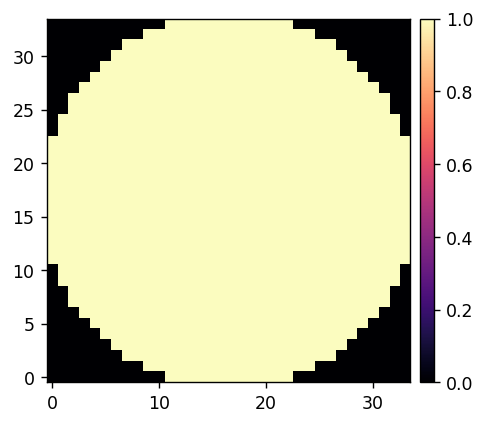

In [2]:
dm_mask = dm.create_mask(Nact=34, return_np=1)
utils.imshow([dm_mask])

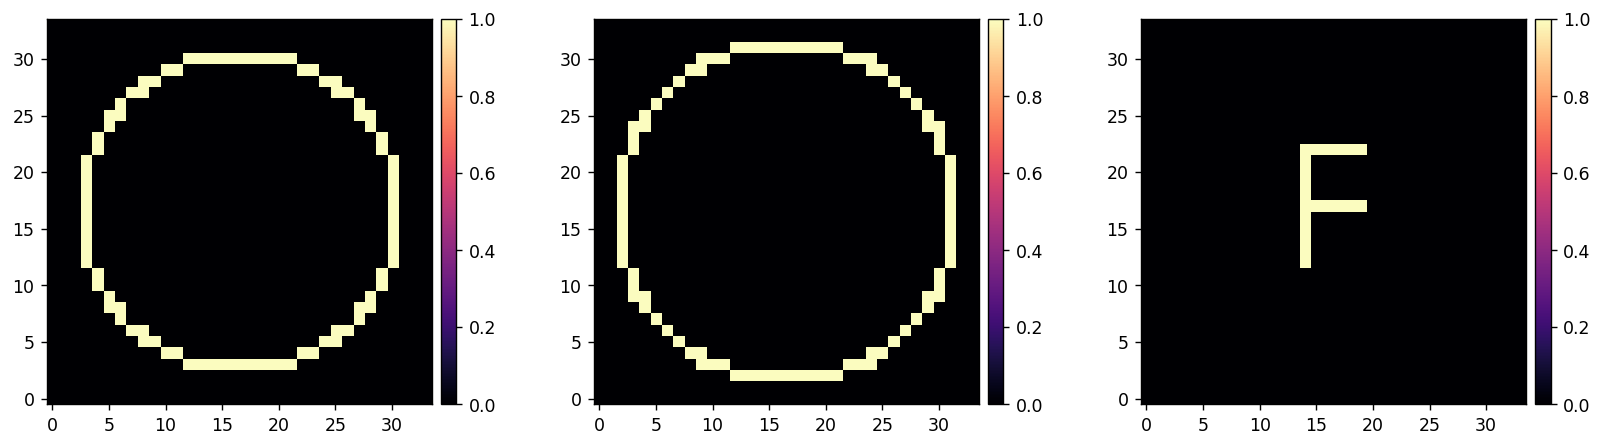

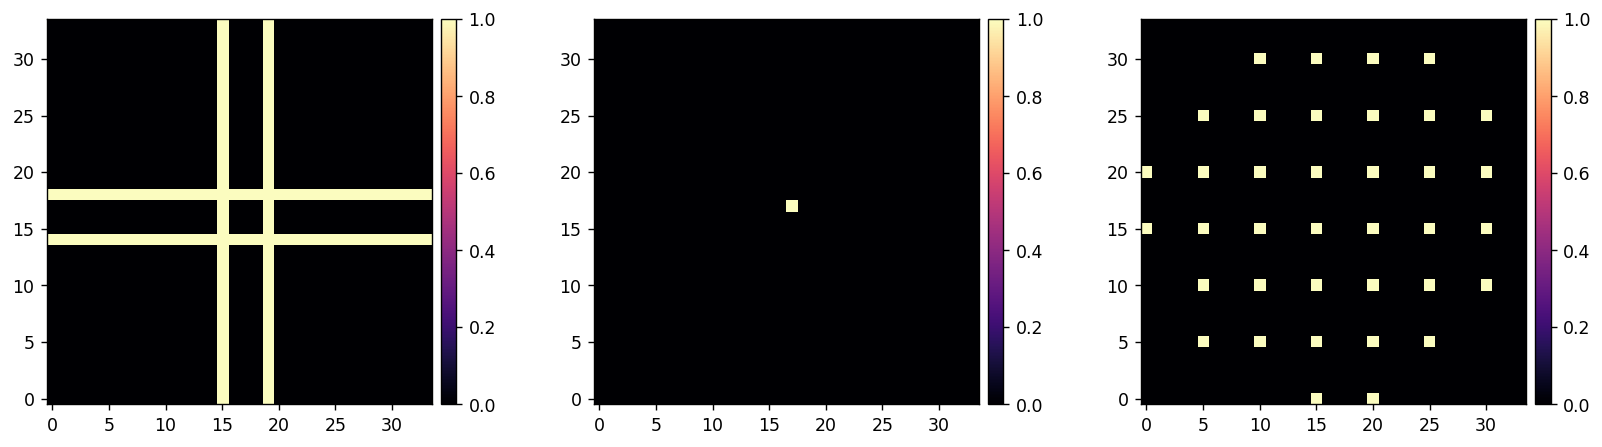

In [3]:
reload(dm)

ring_13 = dm.make_ring(rad=13, Nact=34)
ring_14 = dm.make_ring(rad=14, Nact=34)
ring_15 = dm.make_ring(rad=15, Nact=34)
ring_16 = dm.make_ring(rad=16, Nact=34)
f = dm.make_f()
utils.imshow(
    [ring_14, ring_15, f]
)

cross = dm.make_cross_command(
    xc=[-1, 3], 
    yc=[2,-2],
)

poke = np.zeros((34,34))
poke[17,17] = 1
# poke[25,17] = 1
# poke[18,31] = 1

pokes = np.zeros((34,34))
for i in range(34):
    for j in range(34):
        if i%5==0 and j%5==0:
            pokes[i,j] = 1
pokes *= dm_mask
utils.imshow(
    [cross, poke, pokes]
)

# Align the PSF onto the center of vortex before running PR.

In [4]:
reload(coro_utils)

camsci_channel = 'camsci'

xc, yc = (4580, 2110)
ncamsci = 256
# coro_utils.set_zwo_roi(xc, yc, npsf, client0)

coro_utils.set_cam_roi(xc, yc, ncamsci, client0, cam_name=camsci_channel)
coro_utils.set_cam_exp_time(0.001, client0, cam_name=camsci_channel)
coro_utils.set_cam_gain(120, client0, cam_name=camsci_channel)
coro_utils.set_cam_blacklevel(2, client0, cam_name=camsci_channel)

Set camsci ROI.
Set the camsci exposure time to 1.00e-03s
Set the camsci gain setting to 120.0
Set the camsci blacklevel to 2.0


In [61]:
reload(coro_utils)
coro_utils.move_psf(-5, 0, client0)

In [52]:
reload(coro_utils)
coro_utils.move_psf(0, 5, client0)

In [ ]:
reload(coro_utils)

cam_channel = 'campupil'

xc, yc = (4580, 2110)
ncam = 256
# coro_utils.set_zwo_roi(xc, yc, npsf, client0)

coro_utils.set_cam_roi(xc, yc, ncam, client0, cam_name=cam_channel)
coro_utils.set_cam_exp_time(0.001, client0, cam_name=cam_channel)
coro_utils.set_cam_gain(120, client0, cam_name=cam_channel)
coro_utils.set_cam_blacklevel(2, client0, cam_name=cam_channel)

In [ ]:
reload(coro_utils)
coro_utils.set_fiber_atten(0, client0)


In [ ]:
reload(coro_utils)
coro_utils.move_psf(-10, 0, client0)


In [ ]:
reload(coro_utils)
coro_utils.move_psf(0, -10, client0)

In [ ]:

camfpm_channel = 'camfpm'
dm_channel = 'dm00disp01'

xc, yc = (4580, 2110)
ncam = 256
# coro_utils.set_zwo_roi(xc, yc, npsf, client0)

coro_utils.set_cam_roi(xc, yc, ncam, client0, cam_name=cam_channel)
coro_utils.set_cam_exp_time(0.001, client0, cam_name=cam_channel)
coro_utils.set_cam_gain(120, client0, cam_name=cam_channel)
coro_utils.set_cam_blacklevel(2, client0, cam_name=cam_channel)

In [ ]:
DM_STREAM = ImageStream(dm_channel)

In [ ]:
coro_utils.set_dm(DM_STREAM, 10e-9*ring_15)

In [ ]:
coro_utils.set_dm(DM_STREAM, 10e-9*(ring_15 + cross))